In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from oracle.custom_datasets.BTS import BTS_val_parquet_path, BTS_test_parquet_path, BTS_train_parquet_path

In [2]:
colors = {1: 'mediumaquamarine', 2: 'crimson', 3: 'goldenrod'}
filters = {1: 'g', 2: 'r', 3: 'i'}
markers = {1: 'o', 2: 's', 3: '^'}

In [3]:
val_df = pd.read_parquet(BTS_val_parquet_path)
test_df = pd.read_parquet(BTS_test_parquet_path)


In [4]:
df = pd.concat([val_df, test_df], ignore_index=True)

In [31]:
def plot_ztf_sample(id, save=True):

    gs_kw = dict(width_ratios=[3, 1], height_ratios=[2, 1])
    fig, axd = plt.subplot_mosaic([['left', 'upper right'],
                                ['left', 'lower right']],
                                    gridspec_kw=gs_kw,
                                figsize=(7, 3.3), layout="constrained")
    for k in ['upper right', 'lower right']:
        axd[k].set_xticks([])
        axd[k].set_yticks([])

    sample = df[df['ZTFID'] == id]
    label = sample['bts_class'].to_numpy()[0]

    t = sample['jd'].to_numpy()[0]
    t = t - np.min(t)

    mag = sample['magpsf'].to_numpy()[0]
    mag_err = sample['sigmapsf'].to_numpy()[0]
    band = sample['fid'].to_numpy()[0]

    ra = sample['ra'].to_numpy()[0][0]
    dec = sample['dec'].to_numpy()[0][0]
    drb = sample['drb'].to_numpy()[0][0]
    sgscore = sample['sgscore1'].to_numpy()[0][0]
    scorr = sample['scorr'].to_numpy()[0][0]


    for b in np.unique(band):
        mask = band == b
        axd['left'].errorbar(t[mask], mag[mask], yerr=mag_err[mask], fmt=markers[b], label=filters[b], color=colors[b], mec='white', markersize=10)

    axd['left'].text(0.05, 0.1, f"{id} ({label})", transform=axd['left'].transAxes, fontsize='xx-large', verticalalignment='top')
    axd['left'].set_ylim(top=20.8)

    axd['left'].invert_yaxis()
    axd['left'].set_xlabel('Days since first detection', fontsize='xx-large')
    axd['left'].set_ylabel('AB magnitude', fontsize='xx-large')

    ps_data = sample['ps'].iloc[0]

    img = np.asarray(ps_data).reshape((3, 252, 252))
    img = np.permute_dims(img, (1,2,0))  # swap x and y for correct orientation

    axd['upper right'].imshow(img)


    text = f"RA: {ra:.3f}\nDec: {dec:.3f}\nsgscore: {sgscore:.2f}\nscorr: {scorr:.2f}"

    axd['lower right'].text(0, 0, text, transform=axd['lower right'].transAxes,
                        fontsize='xx-large', color='black', ha='left', va='bottom')   
    axd['lower right'].axis('off') 


    # make legend a separate figure
    fig_legend = plt.figure(figsize=(3, 1))
    ax_legend = fig_legend.add_subplot()
    for b in np.unique(band):
        mask = band == b
        ax_legend.plot([], [], markers[b], label=filters[b], color=colors[b])
    # make it 3 column
    ax_legend.legend(ncol=3)
    ax_legend.axis('off')


    if save:
        fig.savefig(f"{label}_{id}.pdf")
        fig_legend.savefig(f"legend.pdf")
    else:
        plt.show()

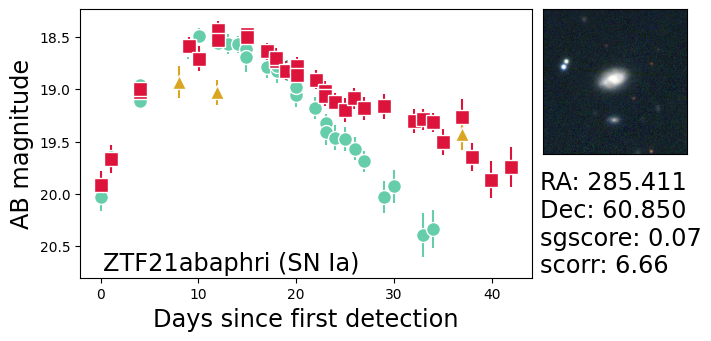

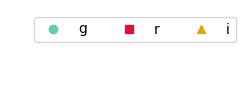

In [32]:
plot_ztf_sample("ZTF21abaphri")

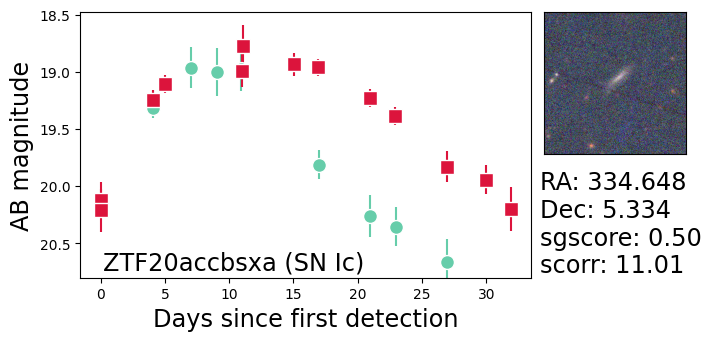

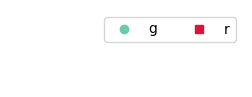

In [33]:
plot_ztf_sample("ZTF20accbsxa")

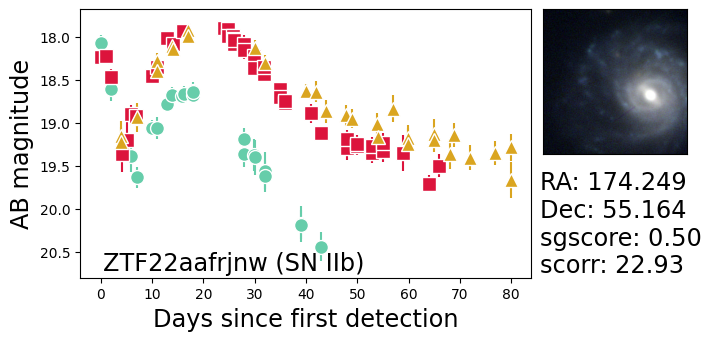

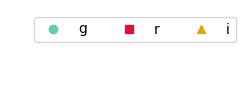

In [34]:
plot_ztf_sample("ZTF22aafrjnw")

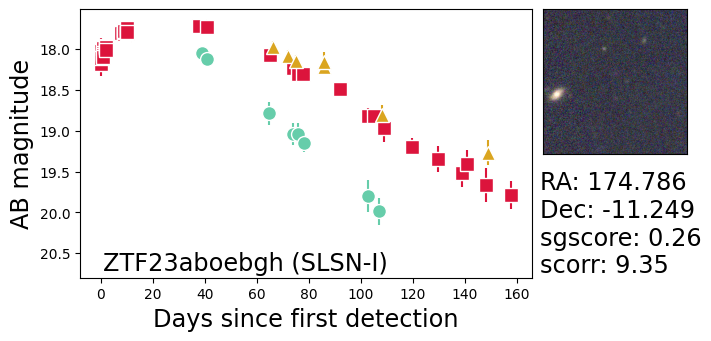

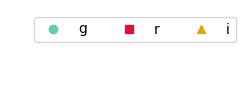

In [35]:
plot_ztf_sample("ZTF23aboebgh")

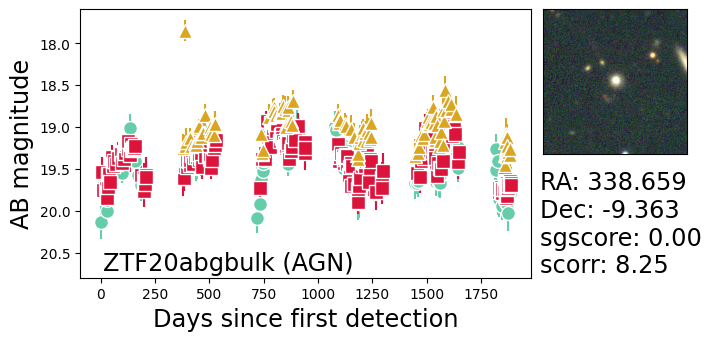

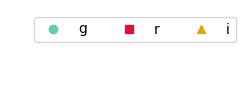

In [36]:
plot_ztf_sample("ZTF20abgbulk")

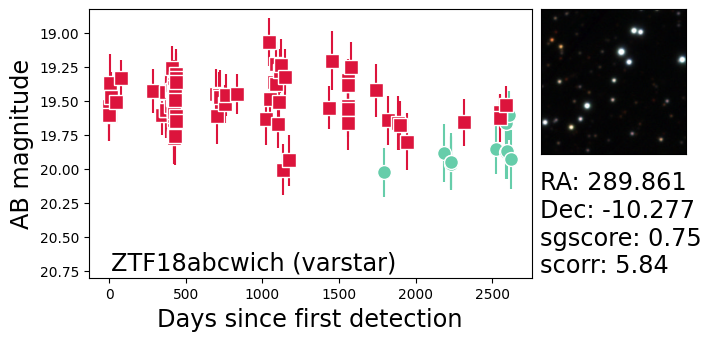

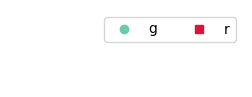

In [37]:
plot_ztf_sample("ZTF18abcwich")

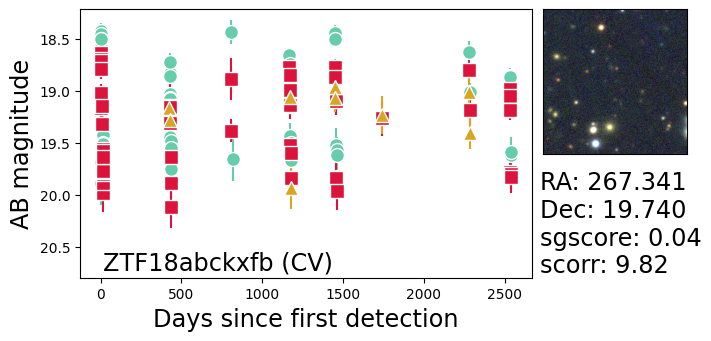

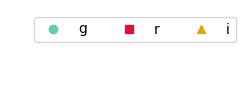

In [38]:
plot_ztf_sample("ZTF18abckxfb")

In [13]:
# shuffle the df
df.sample(frac=1).reset_index(drop=True)

,ZTFID,bts_class,objectId,jd,label,fid,diffmaglim,programid,candid,isdiffpos,...,nondet_jd,nondet_diffmaglim,W1mag,W2mag,W3mag,W4mag,ps,g_reference,r_reference,i_reference
0,ZTF19abpztlw,SN Ia,"[ZTF19abpztlw, ZTF19abpztlw, ZTF19abpztlw, ZTF...","[2458712.8974653, 2458717.939213, 2458717.9741...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, ...","[19.33314514160156, 19.590381622314453, 19.554...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[958397460015015032, 963439210015015007, 96347...","[t, t, t, t, t, t, t, t, t, t, t, t, t, t, t, ...",...,None,None,16.629999,16.593,12.603,9.054,"[0.1764705926179886, 0.062745101749897, 0.2039...",NaN,NaN,NaN
1,ZTF18abncrlw,AGN,"[ZTF18abncrlw, ZTF18abncrlw, ZTF18abncrlw, ZTF...","[2458346.8709606, 2458368.89, 2458369.8121181,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, ...","[20.857738494873047, 20.884862899780273, 20.99...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, ...","[592370963915015005, 614389993915015013, 61531...","[t, t, t, t, t, t, t, t, t, t, t, t, t, t, t, ...",...,None,None,13.631000,12.972,10.547,8.512,"[0.1725490242242813, 0.16078431904315948, 0.01...",NaN,NaN,NaN
2,ZTF23aboebgh,SLSN-I,"[ZTF23aboebgh, ZTF23aboebgh, ZTF23aboebgh, ZTF...","[2460250.0421759, 2460250.0446181, 2460250.047...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[18.144189834594727, 18.514257431030273, 18.42...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2495542172215015099, 2495544612215015033, 249...","[t, t, t, t, t, t, t, t, t, t, t, t, t, t, t, ...",...,None,None,-9.000000,-9.000,-9.000,-9.000,"[0.3294117748737335, 0.18039216101169586, 0.0,...","[0.016010619699954987, 0.01592492125928402, 0....","[0.01588662713766098, 0.015760265290737152, 0....","[0.0157709289342165, 0.016010750085115433, 0.0..."
3,ZTF22aaahklt,SN Ia,"[ZTF22aaahklt, ZTF22aaahklt, ZTF22aaahklt, ZTF...","[2459622.7570718, 2459622.8243056, 2459623.691...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 2, 3, 1, 2, 3, 1, 1, 2, 3, 2, 1, 1, 1, 2, ...","[19.621335983276367, 19.65699577331543, 19.360...","[1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, ...","[1868257072215015012, 1868324302215015011, 186...","[t, t, t, t, t, t, t, t, t, t, t, t, t, t, t, ...",...,None,None,15.738000,15.378,11.560,8.343,"[0.20000000298023224, 0.1568627506494522, 0.23...",NaN,NaN,NaN
4,ZTF22abekkwn,SN Ia,"[ZTF22abekkwn, ZTF22abekkwn, ZTF22abekkwn, ZTF...","[2459823.8455324, 2459823.9076852, 2459824.767...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 2, 1, 2, 2, 1, 1, 2, 1, 1, 2, 2, 1, 2, 1, ...","[20.532678604125977, 20.516529083251953, 20.81...","[2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, ...","[2069345530815015009, 2069407680815015014, 207...","[t, t, t, t, t, t, t, t, t, t, t, t, t, t, t, ...",...,None,None,-9.000000,-9.000,-9.000,-9.000,"[0.29411765933036804, 0.20392157137393951, 0.1...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2992,ZTF22aafoqrd,SN Ia,"[ZTF22aafoqrd, ZTF22aafoqrd, ZTF22aafoqrd, ZTF...","[2459682.8163773, 2459687.8168981, 2459687.869...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 3, 2, 1, 1, 2, 3, 3, 2, 1, 2, 3, 1, 1, 2, ...","[19.587181091308594, 19.156837463378903, 19.24...","[1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, ...","[1928316372915015000, 1933316892915015000, 193...","[t, t, t, t, t, t, t, t, t, t, t, t, t, t, t, ...",...,None,None,-9.000000,-9.000,-9.000,-9.000,"[0.027450980618596077, 0.027450980618596077, 0...",NaN,NaN,NaN
2993,ZTF20acdalpf,SN Ia,"[ZTF20acdalpf, ZTF20acdalpf, ZTF20acdalpf, ZTF...","[2459115.7598148, 2459116.738669, 2459117.7426...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 2, 1, 2, ...","[20.519939422607425, 20.4644718170166, 20.3243...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,